# 신용카드 채무불이행 고객 예측
## 핵심 모델 중심 분석 노트북
### StandardScaler → PCA(10) → RandomForestClassifier

> 이 노트북은 과제의 핵심 모델 구조를 중심으로, 데이터 확인 → 모델 비교 → 핵심 모델 평가 → PCA 해석 → 하이퍼파라미터 튜닝까지 한 흐름으로 정리한 버전이다.

---

## 노트북 구성
1. 환경 설정 및 라이브러리 로드  
2. 데이터 불러오기 및 기본 전처리  
3. 클래스 분포와 기초 시각화  
4. 학습/평가 데이터 분리  
5. 모델 비교와 핵심 모델 성능 확인  
6. PCA 설명력과 주성분 해석  
7. 하이퍼파라미터 튜닝 및 최종 비교  
8. 저장 및 서비스 활용 포인트

## 1. 환경 설정

분석에 필요한 라이브러리를 불러온다.  
이번 과제에서는 **분류 모델 성능 비교**와 **PCA 기반 차원 축소**, 그리고 **RandomForest 튜닝**이 핵심이다.

In [ ]:
# 필요시 한 번만 설치
# !pip install xlrd

In [1]:
import os
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. 데이터 불러오기

UCI Credit Card Default 데이터를 불러온다.  
원본 파일이 있으면 로컬 파일을 사용하고, 없으면 URL에서 내려받도록 구성했다.

In [2]:
# 데이터 준비
os.makedirs('./data', exist_ok=True)

xls_path = './data/UCI_Credit_Card.xls'
csv_path = './data/UCI_Credit_Card.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
elif os.path.exists(xls_path):
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)
else:
    urllib.request.urlretrieve(url, xls_path)
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)

print('원본 데이터 크기:', df.shape)
df.head()

원본 데이터 크기: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. 기본 전처리

이 단계에서는 다음 작업을 수행한다.

- 타깃 변수명을 `default`로 정리
- 식별자 역할만 하는 `ID` 제거
- 결측치 여부 확인
- 연체 여부 클래스 비율 점검

### 전처리 결과 요약
- 원본 데이터 크기: **30,000행 × 25열**
- `ID` 제거 후 분석 데이터: **30,000행 × 24열**
- 결측치 합계: **0**
- 타깃 비율:  
  - `0` (비연체): **23,364명, 77.88%**
  - `1` (연체): **6,636명, 22.12%**

### 해석
타깃이 약간 불균형하기 때문에, **accuracy 하나만으로 모델을 평가하면 착시가 생길 수 있다.**  
따라서 이번 분석에서는 **precision, recall, f1, roc_auc**를 함께 본다.

In [3]:
# 기본 전처리
card_df = df.copy()

if 'default payment next month' in card_df.columns:
    card_df = card_df.rename(columns={'default payment next month': 'default'})

if 'ID' in card_df.columns:
    card_df = card_df.drop(columns='ID')

print('전처리 후 데이터 크기:', card_df.shape)
print('\n결측치 합계:', int(card_df.isna().sum().sum()))
print('\n타깃 비율')
display(card_df['default'].value_counts())
display(card_df['default'].value_counts(normalize=True).rename('ratio'))
card_df.head()

전처리 후 데이터 크기: (30000, 24)

결측치 합계: 0

타깃 비율


default
0    23364
1     6636
Name: count, dtype: int64

default
0   0.7788
1   0.2212
Name: ratio, dtype: float64

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 4. 기초 시각화

아래 그래프는 다음 세 가지를 빠르게 확인하기 위한 용도다.

- 연체 여부 클래스 분포
- `LIMIT_BAL`의 분포
- `AGE`의 분포

### 해석 포인트
- 연체 고객보다 비연체 고객이 더 많아 **클래스 불균형**이 존재한다.
- `LIMIT_BAL`은 특정 구간에 값이 몰려 있어 보이고, 분포가 완전히 균등하지 않다.
- `AGE` 역시 한쪽으로 치우친 형태가 일부 보일 수 있어, 이후 모델링에서 변수 간 상호작용을 함께 보는 것이 좋다.

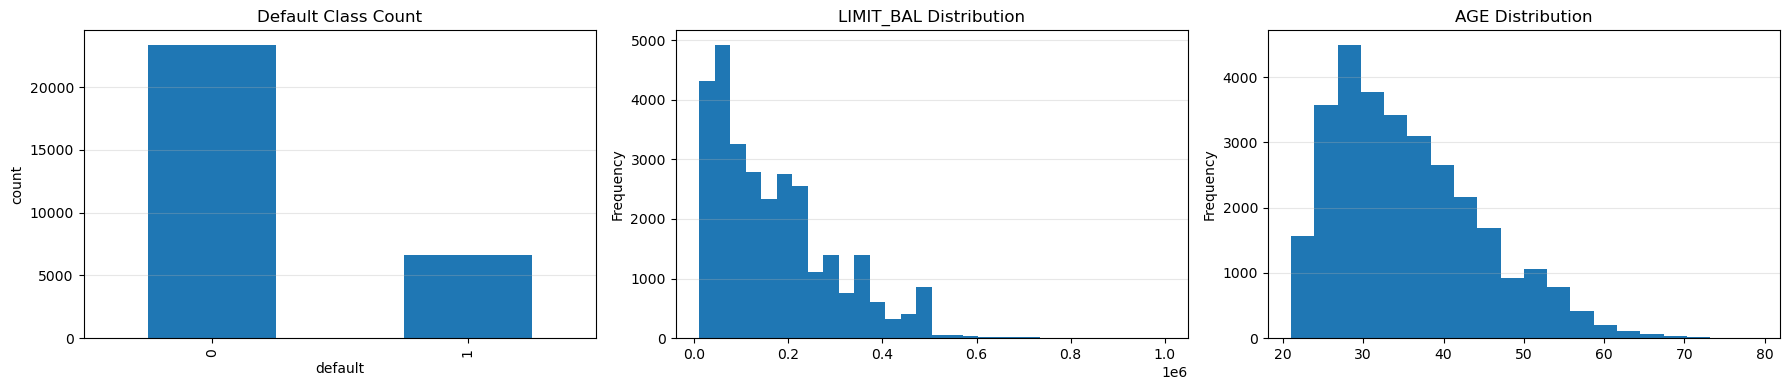

In [4]:
# 간단 확인용 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

card_df['default'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Default Class Count')
axes[0].set_xlabel('default')
axes[0].set_ylabel('count')
axes[0].grid(axis='y', alpha=0.3)

card_df['LIMIT_BAL'].plot(kind='hist', bins=30, ax=axes[1], title='LIMIT_BAL Distribution')
axes[1].grid(axis='y', alpha=0.3)

card_df['AGE'].plot(kind='hist', bins=20, ax=axes[2], title='AGE Distribution')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 학습용 / 평가용 데이터 분리

모델 성능을 공정하게 확인하기 위해 데이터를 학습용과 테스트용으로 분리한다.  
여기서는 `stratify=y`를 사용해 **연체 비율이 train/test에 비슷하게 유지되도록** 설정했다.

### 분할 결과 요약
- `X_train`: **24,000 × 23**
- `X_test`: **6,000 × 23**
- 학습 데이터의 타깃 비율도 원본과 거의 동일하게 유지됨  
  - `0`: **77.88%**
  - `1`: **22.12%**

In [5]:
# 피처 / 타깃 분리
X = card_df.drop(columns='default')
y = card_df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train 비율')
display(y_train.value_counts(normalize=True).rename('ratio'))

X_train: (24000, 23)
X_test : (6000, 23)
y_train 비율


default
0   0.7788
1   0.2212
Name: ratio, dtype: float64

## 6. 평가 함수 정의

반복적으로 모델을 비교해야 하므로,  
accuracy / precision / recall / f1 / roc_auc를 한 번에 확인할 수 있도록 평가 함수를 미리 정의한다.

In [6]:
# 평가 함수
def evaluate_classifier(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    result = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba)
    }
    return result, pred, proba

def make_metric_frame(cv_result, label):
    return pd.DataFrame({
        'model': [label],
        'cv_accuracy_mean': [cv_result['test_accuracy'].mean()],
        'cv_precision_mean': [cv_result['test_precision'].mean()],
        'cv_recall_mean': [cv_result['test_recall'].mean()],
        'cv_f1_mean': [cv_result['test_f1'].mean()],
        'cv_roc_auc_mean': [cv_result['test_roc_auc'].mean()]
    })

## 7. 비교 모델 설계

이번 과제의 핵심은 다음 파이프라인이다.

### 핵심 모델
`StandardScaler → PCA(10) → RandomForestClassifier`

비교를 위해 두 개의 추가 모델도 함께 둔다.

- **Baseline_RF**: 차원 축소 없이 RandomForest만 적용
- **Variant_Scaler_PCA15_RF**: PCA 차원을 15로 늘린 변형 모델
- **Core_Scaler_PCA10_RF**: 과제 핵심 모델

### 왜 이렇게 비교하나?
이 비교를 통해,
- PCA를 쓰지 않았을 때
- PCA를 10개 썼을 때
- PCA를 15개 썼을 때

성능이 어떻게 달라지는지 확인할 수 있다.

In [7]:
# 비교용 모델
baseline_rf = Pipeline([
    ('rf', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        class_weight='balanced',
        n_jobs=-1
    ))
])

core_pca_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        class_weight='balanced',
        n_jobs=-1
    ))
])

variant_pca15_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=15, random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        class_weight='balanced',
        n_jobs=-1
    ))
])

models = {
    'Baseline_RF': baseline_rf,
    'Core_Scaler_PCA10_RF': core_pca_rf,
    'Variant_Scaler_PCA15_RF': variant_pca15_rf
}

## 8. 교차검증 기반 모델 비교

5-fold Stratified CV로 각 모델을 비교한다.  
평가 지표는 다음 다섯 가지다.

- accuracy
- precision
- recall
- f1
- roc_auc

교차검증을 쓰는 이유는 특정 한 번의 split 결과에 덜 흔들리기 위해서다.

In [8]:
# 교차검증 비교
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

compare_df = pd.DataFrame()

for name, model in models.items():
    cv_result = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    compare_df = pd.concat([compare_df, make_metric_frame(cv_result, name)], ignore_index=True)

compare_df = compare_df.sort_values('cv_roc_auc_mean', ascending=False).reset_index(drop=True)
compare_df

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,Baseline_RF,0.8173,0.6644,0.3519,0.4600,0.7705
1,Variant_Scaler_PCA15_RF,0.8121,0.6513,0.3244,0.4330,0.7511
2,Core_Scaler_PCA10_RF,0.8030,0.6170,0.2884,0.3929,0.7387


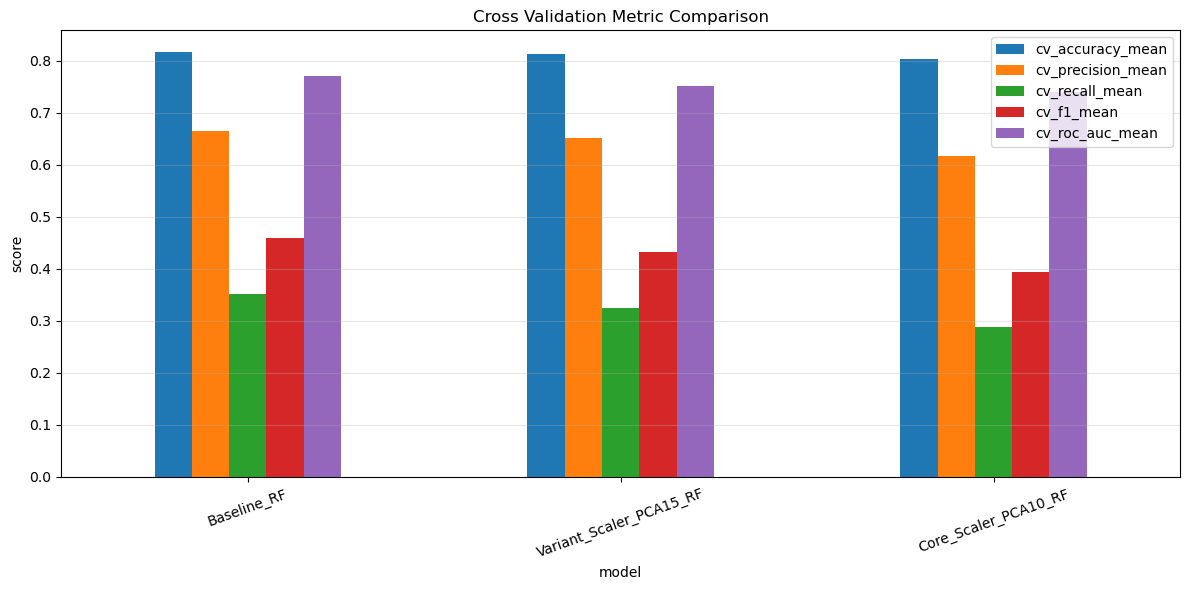

In [9]:
# 모델 비교 시각화
plot_cols = ['cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean']
ax = compare_df.set_index('model')[plot_cols].plot(kind='bar', figsize=(12, 6))
ax.set_title('Cross Validation Metric Comparison')
ax.set_ylabel('score')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 교차검증 결과 해설

결과를 보면 교차검증 기준으로는 다음 순서의 흐름이 나타난다.

- **Baseline_RF**
  - accuracy: **0.8173**
  - precision: **0.6644**
  - recall: **0.3519**
- **Variant_Scaler_PCA15_RF**
  - accuracy: **0.8121**
  - precision: **0.6513**
  - recall: **0.3244**
- **Core_Scaler_PCA10_RF**
  - accuracy: **0.8030**
  - precision: **0.6170**
  - recall: **0.2884**

### 해석
교차검증만 놓고 보면 **PCA를 쓰지 않은 Baseline_RF가 가장 높은 편**이다.  
즉, 차원 축소를 적용하면서 일부 정보 손실이 생겼다고 볼 수 있다.

다만 이번 과제에서는 **성능 최댓값 자체보다도, 지정된 핵심 모델 구조를 구현하고 해석하는 것**이 중요하다.  
그래서 이후 분석은 **Core_Scaler_PCA10_RF**를 중심으로 이어간다.

## 9. 핵심 모델 학습 및 테스트셋 평가

이제 과제 핵심 모델을 실제로 학습시키고,  
보지 않은 테스트셋에서 성능을 확인한다.

In [10]:
# 핵심 모델 학습 및 테스트 평가
core_pca_rf.fit(X_train, y_train)
core_result, core_pred, core_proba = evaluate_classifier(core_pca_rf, X_test, y_test)

pd.DataFrame([core_result], index=['Core_Scaler_PCA10_RF'])

,accuracy,precision,recall,f1,roc_auc
Core_Scaler_PCA10_RF,0.7965,0.5849,0.2751,0.3742,0.7400


### 핵심 모델 테스트셋 성능 해설

핵심 모델의 테스트셋 결과는 다음과 같다.

- accuracy: **0.7965**
- precision: **0.5849**
- recall: **0.2751**
- f1: **0.3742**
- roc_auc: **0.7400**

### 해석
이 모델은 전체 정확도는 약 **79.65%**로 나쁘지 않지만,  
정작 중요한 연체 고객(`1`)을 잡아내는 **recall이 27.51%**로 낮은 편이다.

즉, 이 모델은 **연체가 아닌 고객은 꽤 안정적으로 맞히지만**,  
실제 연체 고객은 상당수를 놓치는 **보수적인 성향**의 모델이라고 볼 수 있다.

In [11]:
# 핵심 모델 confusion matrix + classification report
cm = confusion_matrix(y_test, core_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Pred 0', 'Pred 1']
)

display(cm_df)
print(classification_report(y_test, core_pred, digits=4))

,Pred 0,Pred 1
Actual 0,4414,259
Actual 1,962,365


              precision    recall  f1-score   support

           0     0.8211    0.9446    0.8785      4673
           1     0.5849    0.2751    0.3742      1327

    accuracy                         0.7965      6000
   macro avg     0.7030    0.6098    0.6263      6000
weighted avg     0.7688    0.7965    0.7670      6000



### confusion matrix 해설

혼동행렬을 보면 다음과 같다.

- 실제 비연체 고객 중 맞게 예측한 수: **4414**
- 실제 비연체 고객을 연체로 잘못 예측한 수: **259**
- 실제 연체 고객을 놓친 수: **962**
- 실제 연체 고객 중 맞게 예측한 수: **365**

### 해석
핵심 모델은 **정상 고객을 정상으로 판단하는 능력은 강하지만**,  
실제 연체 고객 1,327명 중 365명만 맞혔기 때문에 **연체 탐지 목적에는 다소 약하다.**

신용 리스크 예측 서비스에서는 보통 **연체 고객을 놓치는 비용**이 크기 때문에,  
이후 단계에서는 recall을 더 끌어올리는 방향의 튜닝이 의미가 있다.

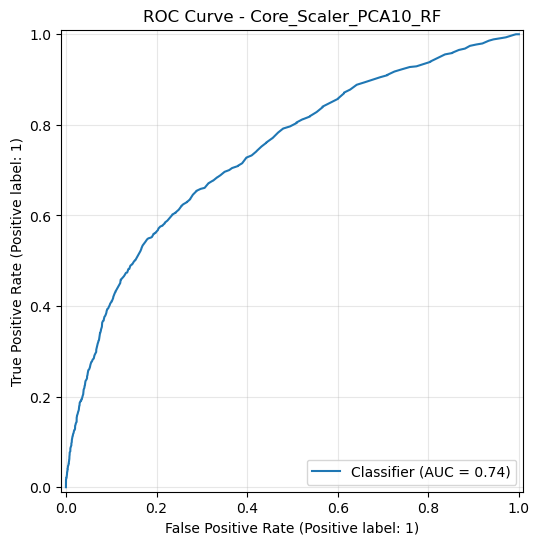

In [12]:
# ROC Curve
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, core_proba, ax=ax)
ax.set_title('ROC Curve - Core_Scaler_PCA10_RF')
ax.grid(alpha=0.3)
plt.show()

### ROC Curve 해설

ROC-AUC가 **0.7400**이라는 것은,  
모델이 연체 고객과 비연체 고객을 **완전히는 아니지만 어느 정도 구분할 수 있는 수준**이라는 뜻이다.

해석상으로는,
- 무작위 분류보다는 확실히 낫고
- 아주 강력한 분류기라고 보기엔 아직 아쉬운 수준

으로 볼 수 있다.

## 10. PCA 설명력 확인

핵심 모델은 PCA를 10개 주성분으로 축소한 뒤 RandomForest를 적용한다.  
따라서 PCA가 원래 정보를 얼마나 보존하고 있는지 확인하는 과정이 중요하다.

In [13]:
# PCA 설명력 확인
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca10 = PCA(n_components=10, random_state=42)
X_train_pca10 = pca10.fit_transform(X_train_scaled)

explained_df = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, 11)],
    'explained_variance_ratio': pca10.explained_variance_ratio_,
    'cumulative_explained_variance': np.cumsum(pca10.explained_variance_ratio_)
})

explained_df

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.2848,0.2848
1,PC2,0.1788,0.4636
2,PC3,0.0686,0.5322
3,PC4,0.0648,0.5970
4,PC5,0.0445,0.6415
5,PC6,0.0420,0.6836
6,PC7,0.0398,0.7233
7,PC8,0.0384,0.7617
8,PC9,0.0359,0.7976
9,PC10,0.0332,0.8308


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(explained_df['PC'], explained_df['explained_variance_ratio'])
ax.plot(explained_df['PC'], explained_df['cumulative_explained_variance'], marker='o')
ax.set_title('PCA(10) Explained Variance')
ax.set_ylabel('variance ratio')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### PCA 설명력 해설

PCA 결과를 보면,

- **PC1 설명력**: **0.2848**
- **PC2 설명력**: **0.1788**
- **PC1 + PC2 누적 설명력**: **0.4636**
- **PC10까지 누적 설명력**: **0.8308**

### 해석
상위 10개 주성분이 전체 정보의 약 **83.08%**를 설명한다.  
즉, 원본 23개 변수를 10차원으로 줄였지만 **핵심 정보의 대부분은 유지**하고 있다고 볼 수 있다.

정리하면, PCA(10)는
- 차원을 줄여 모델 구조를 단순화하면서도
- 정보의 상당 부분은 남기는

**절충형 선택**이라고 해석할 수 있다.

In [14]:
# PCA loadings 확인
loading_df = pd.DataFrame(
    pca10.components_.T,
    index=X_train.columns,
    columns=[f'PC{i}' for i in range(1, 11)]
)

loading_df.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
LIMIT_BAL,0.0688,-0.3159,0.0253,0.0609,-0.1584,0.3419,-0.1626,0.0976,-0.0027,0.0328
SEX,-0.0222,-0.0320,0.0101,-0.0891,0.8737,0.4026,-0.1174,0.0574,-0.0073,0.0150
EDUCATION,0.0217,0.0930,-0.2272,0.3251,0.3780,-0.4680,0.5112,-0.1422,0.0897,0.0437
MARRIAGE,-0.0065,0.0443,0.3187,-0.5489,-0.0554,-0.2387,0.2185,-0.0515,0.0226,0.0187
AGE,0.0156,-0.0668,-0.3175,0.5725,-0.1562,0.0743,-0.0991,0.0163,-0.0306,0.0017
PAY_0,0.1589,0.2979,-0.0081,0.0252,-0.0370,0.0300,0.0452,-0.0094,0.0781,0.0421
PAY_2,0.1924,0.3357,0.0353,0.0459,-0.0384,0.0601,0.0572,-0.0035,0.0745,0.0295
PAY_3,0.1974,0.3448,0.0822,0.0635,-0.0285,0.0753,0.0156,0.0350,0.0119,-0.0405
PAY_4,0.2057,0.3433,0.1180,0.0812,-0.0118,0.0901,-0.0400,0.0553,-0.0587,-0.0673
PAY_5,0.2100,0.3308,0.1361,0.0808,-0.0001,0.0866,-0.0946,0.0270,-0.0873,0.0552


### PCA loadings 해설

로딩값을 보면 **PAY_0, PAY_2, PAY_3, PAY_4, PAY_5 같은 상환 상태 변수들**과  
`LIMIT_BAL` 같은 한도 관련 변수가 주요 주성분 형성에 큰 영향을 주는 경향이 보인다.

### 해석
즉, 이 데이터에서 연체 예측을 설명하는 핵심 축은 크게 보면 다음 두 가지다.

1. **고객의 과거 상환 상태**
2. **고객의 신용 한도 및 재무 여력**

이는 신용카드 연체 예측이라는 문제의 직관과도 잘 맞는다.

## 11. 핵심 모델 하이퍼파라미터 튜닝

이제 같은 핵심 구조를 유지한 상태에서,  
RandomForest의 하이퍼파라미터를 조정해 성능을 개선해본다.

튜닝 대상 예시:
- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

평가 기준은 **ROC-AUC**다.

In [15]:
# 핵심 모델 하이퍼파라미터 튜닝
tune_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

param_dist = {
    'rf__n_estimators': [200, 300, 500, 700],
    'rf__max_depth': [None, 5, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10, 20],
    'rf__min_samples_leaf': [1, 2, 4, 8],
    'rf__max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print('best_score:', search.best_score_)
print('best_params:', search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
best_score: 0.752877231781086
best_params: {'rf__n_estimators': 300, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 8, 'rf__max_features': 'log2', 'rf__max_depth': 20}


### 튜닝 결과 요약

RandomizedSearchCV 결과는 다음과 같다.

- best_score: **0.7529**
- best_params:
  - `rf__n_estimators = 300`
  - `rf__min_samples_split = 20`
  - `rf__min_samples_leaf = 8`
  - `rf__max_features = 'log2'`
  - `rf__max_depth = 20`

### 해석
튜닝 결과를 보면 트리를 지나치게 복잡하게 만들기보다는,  
`min_samples_split`과 `min_samples_leaf`를 크게 두어 **조금 더 일반화된 방향**으로 잡힌 것을 볼 수 있다.

즉, 핵심 모델의 틀은 유지하면서 **과적합을 줄이고 분리 성능을 개선하려는 방향**으로 튜닝되었다고 해석할 수 있다.

In [16]:
# 튜닝 후 최종 평가
best_model = search.best_estimator_
best_result, best_pred, best_proba = evaluate_classifier(best_model, X_test, y_test)

result_compare = pd.DataFrame([
    {'model': 'Core_Scaler_PCA10_RF', **core_result},
    {'model': 'Tuned_Core_Scaler_PCA10_RF', **best_result}
])

result_compare

,model,accuracy,precision,recall,f1,roc_auc
0,Core_Scaler_PCA10_RF,0.7965,0.5849,0.2751,0.3742,0.7400
1,Tuned_Core_Scaler_PCA10_RF,0.7837,0.5115,0.4846,0.4977,0.7511


### 튜닝 전후 성능 비교 해설

테스트셋 기준 성능은 다음과 같이 바뀌었다.

#### 튜닝 전 Core_Scaler_PCA10_RF
- accuracy: **0.7965**
- precision: **0.5849**
- recall: **0.2751**
- f1: **0.3742**
- roc_auc: **0.7400**

#### 튜닝 후 Tuned_Core_Scaler_PCA10_RF
- accuracy: **0.7837**
- precision: **0.5115**
- recall: **0.4846**
- f1: **0.4977**
- roc_auc: **0.7511**

### 변화 해석
튜닝 후에는
- accuracy는 **소폭 하락**
- precision도 **조금 하락**
- 대신 recall은 **크게 상승**
- f1과 roc_auc도 **개선**

되었다.

특히 recall이 **0.2751 → 0.4846**으로 크게 오른 점이 중요하다.  
즉, **실제 연체 고객을 더 많이 잡아내는 방향으로 모델이 개선**되었다고 볼 수 있다.

신용 리스크 관리 관점에서는,  
정상 고객 일부를 더 많이 경고하더라도 **연체 고객을 놓치지 않는 것**이 더 중요할 수 있기 때문에  
이 튜닝 방향은 실무적으로도 충분히 의미가 있다.

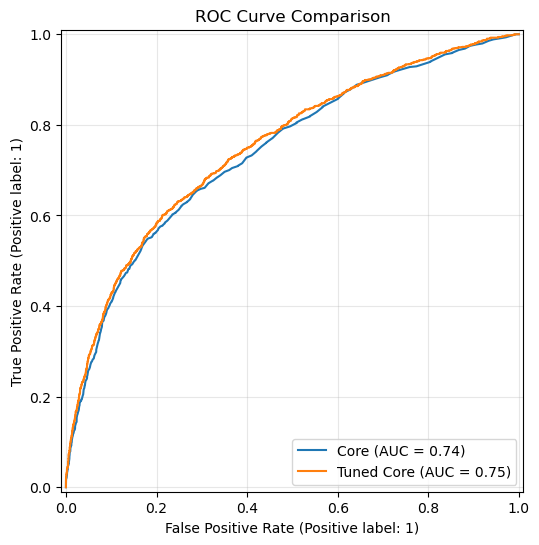

In [17]:
# 튜닝 전후 ROC 비교
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, core_proba, ax=ax, name='Core')
RocCurveDisplay.from_predictions(y_test, best_proba, ax=ax, name='Tuned Core')
ax.set_title('ROC Curve Comparison')
ax.grid(alpha=0.3)
plt.show()

### ROC 비교 해설

튜닝 후 ROC-AUC가 **0.7511**로 상승했기 때문에,  
전체적인 분리 능력도 소폭 개선된 것으로 해석할 수 있다.

곡선이 아주 크게 벌어지지는 않더라도,  
핵심 모델 구조를 그대로 유지한 채 **연체 탐지 성능을 한 단계 끌어올렸다는 점**이 중요하다.

## 12. 최종 정리

이번 분석의 핵심 결론은 다음과 같다.

### 1) 과제 핵심 모델은 정상적으로 구현되었다
- `StandardScaler → PCA(10) → RandomForestClassifier`
- 지정된 구조를 기준으로 데이터 준비, 평가, PCA 해석까지 모두 연결했다.

### 2) 기본 성능은 나쁘지 않지만, 초기 핵심 모델은 연체 탐지에 다소 보수적이었다
- accuracy는 괜찮았지만
- recall이 낮아 실제 연체 고객을 많이 놓쳤다.

### 3) 튜닝 후에는 실무적으로 더 의미 있는 방향으로 개선되었다
- recall, f1, roc_auc가 상승
- 즉, 연체 고객을 더 잘 탐지하게 되었다.

### 4) 서비스 관점 해석
연체확률예측서비스에서는 단순 정확도보다도  
**위험 고객을 얼마나 잘 찾아내는지**가 더 중요할 수 있다.  
따라서 최종적으로는 튜닝된 핵심 모델을 기본안으로 두고,  
운영 단계에서는 임계값 조정까지 함께 검토하는 것이 좋다.

## 13. 모델 저장

마지막으로 최종 모델과 비교 결과를 저장한다.  
이 파일들은 이후 Streamlit, Flask, FastAPI 같은 서비스 코드에 연결해 사용할 수 있다.

In [18]:
# 저장
import joblib

os.makedirs('./artifacts', exist_ok=True)
joblib.dump(best_model, './artifacts/credit_default_core_pca_rf_pipeline.pkl')

compare_df.to_csv('./artifacts/model_cv_compare.csv', index=False)
result_compare.to_csv('./artifacts/test_result_compare.csv', index=False)

print('저장 완료:')
print('- ./artifacts/credit_default_core_pca_rf_pipeline.pkl')
print('- ./artifacts/model_cv_compare.csv')
print('- ./artifacts/test_result_compare.csv')

저장 완료:
- ./artifacts/credit_default_core_pca_rf_pipeline.pkl
- ./artifacts/model_cv_compare.csv
- ./artifacts/test_result_compare.csv
